In [ ]:
 # Install required libraries (run once)
!pip install fastf1 matplotlib seaborn pandas numpy scikit-learn plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 11.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 6.8 MB/s eta 0:00:00
  Created wheel for msgpack: filename=msgpack-1.0.2-cp312-cp312-linux_x86_64.whl size=15820 sha256=ad1e65f3562cdec04bda04a90b5746ade93ae2f3b292cb6b9fdca6995c1ee977
  Stored in directory: /root/.cache/pip/wheels/67/a6/40/eda0983e595bbf3841af96dbff2340be72dfac96796fc3d578
Successfully built msgpack
  Attempting uninstall: msgpack
    Found existing installation: msgpack 1.1.2
    Uninstalling msgpack-1.1.2:
      Successfully uninstalled msgpack-1.1.2
  Attempting uninstall: websocke

In [ ]:
# Imports and cache setup
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display, HTML

import os
# create cache dir
if not os.path.exists('f1_cache'):
    os.makedirs('f1_cache')
fastf1.Cache.enable_cache('f1_cache')

# Plot style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)


In [ ]:
# PARAMETERS: choose the race and drivers here
# Default: Bahrain Grand Prix 2023
YEAR = 2025
EVENT_NAME = 'Qatar Grand Prix'   # change to desired event name (e.g., 'Monaco Grand Prix')
SESSION = 'R'  # 'R' for Race, 'Q' for Qualifying, 'FP1' etc.

# Drivers to compare - use driver codes (e.g., 'VER','LEC','HAM','ALO')
DRIVERS = ['PIA', 'NOR', 'VER', 'ANT', 'RUS']  # modify as needed

# For telemetry comparisons (heavy), pick up to 2 drivers:
TELEMETRY_DRIVERS = ['NOR', 'VER']

print(f"Configuration -> Year: {YEAR}, Event: {EVENT_NAME}, Session: {SESSION}, Drivers: {DRIVERS}")

Configuration -> Year: 2025, Event: Qatar Grand Prix, Session: R, Drivers: ['PIA', 'NOR', 'VER', 'ANT', 'RUS']


In [ ]:
# Load session data (this will download and cache if not present)
print('Loading session, please wait...')
session = fastf1.get_session(YEAR, EVENT_NAME, SESSION)
session.load(laps=True, telemetry=False, weather=True, messages=False)
print('Session loaded.')

# Extract datasets
laps = session.laps    # lap-level DataFrame-like object
results = session.results if hasattr(session, 'results') else None
weather = None
try:
    weather = session.weather_data
except Exception:
    weather = None

print('Available datasets:')
print('- laps:', laps.shape)
print('- results:', None if results is None else results.shape)
print('- weather:', None if weather is None else getattr(weather, 'shape', 'loaded'))

events      WARNING 	Correcting user input 'Qatar Grand Prix' to 'Qatar Grand Prix'


Loading session, please wait...


core           INFO 	Loading data for Qatar Grand Prix - Race [v3.7.0]
INFO:fastf1.fastf1.core:Loading data for Qatar Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data fo

Session loaded.
Available datasets:
- laps: (1067, 31)
- results: (20, 22)
- weather: (149, 8)


In [ ]:
# --- Section 5: Prepare Per-Driver and Combined DataFrames ---
# Clean lap times, compute LapTimeSeconds, and mark pit-in/out laps.

def prepare_driver_laps(laps_df, driver_code):
    # Use new FastF1 API call
    df = laps_df.pick_drivers(driver_code).reset_index(drop=True).copy()

    # Compute LapTimeSeconds
    if 'LapTime' in df.columns:
        df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds()

    # Mark pit laps
    df['is_pitlap'] = df.get('PitInTime').notna() | df.get('PitOutTime').notna()

    # Compute stint lap number if 'Stint' info exists
    if 'Stint' in df.columns:
        df = df.sort_values('LapNumber')
        df['StintLap'] = df.groupby('Stint').cumcount() + 1

    # Add explicit driver label
    df['Driver'] = driver_code

    return df


# Prepare individual driver DataFrames
driver_dfs = {}
for d in DRIVERS:
    try:
        driver_dfs[d] = prepare_driver_laps(laps, d)
    except Exception as e:
        print(f"⚠️ Error preparing data for {d}: {e}")

# Combine all drivers’ data safely
combined = pd.concat(driver_dfs.values(), ignore_index=True)

print(f"✅ Combined DataFrame created successfully! Shape: {combined.shape}")
display(combined.head(10))

✅ Combined DataFrame created successfully! Shape: (285, 34)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds,is_pitlap,StintLap
0,0 days 01:00:09.392000,PIA,81,NaT,1.0,1.0,NaT,NaT,NaT,0 days 00:00:28.924000,...,NaT,1,1.0,None,,False,False,NaN,False,1
1,0 days 01:01:36.542000,PIA,81,0 days 00:01:27.150000,2.0,1.0,NaT,NaT,0 days 00:00:32.074000,0 days 00:00:29.317000,...,NaT,1,1.0,None,,False,True,87.150,False,2
2,0 days 01:03:03.472000,PIA,81,0 days 00:01:26.930000,3.0,1.0,NaT,NaT,0 days 00:00:32.099000,0 days 00:00:29.235000,...,NaT,1,1.0,None,,False,True,86.930,False,3
3,0 days 01:04:30.689000,PIA,81,0 days 00:01:27.217000,4.0,1.0,NaT,NaT,0 days 00:00:32.261000,0 days 00:00:29.397000,...,NaT,1,1.0,None,,False,True,87.217,False,4
4,0 days 01:05:57.588000,PIA,81,0 days 00:01:26.899000,5.0,1.0,NaT,NaT,0 days 00:00:32.031000,0 days 00:00:29.438000,...,NaT,1,1.0,None,,False,True,86.899,False,5
5,0 days 01:07:24.308000,PIA,81,0 days 00:01:26.720000,6.0,1.0,NaT,NaT,0 days 00:00:32.036000,0 days 00:00:29.295000,...,NaT,1,1.0,None,,False,True,86.720,False,6
6,0 days 01:09:02.774000,PIA,81,0 days 00:01:38.466000,7.0,1.0,NaT,NaT,0 days 00:00:32.079000,0 days 00:00:34.188000,...,NaT,124,1.0,None,,False,False,98.466,False,7
7,0 days 01:11:30.140000,PIA,81,0 days 00:02:27.366000,8.0,1.0,NaT,NaT,0 days 00:00:58.262000,0 days 00:00:45.165000,...,NaT,4,1.0,None,,False,False,147.366,False,8
8,0 days 01:13:52.802000,PIA,81,0 days 00:02:22.662000,9.0,1.0,NaT,NaT,0 days 00:00:55.865000,0 days 00:00:44.121000,...,NaT,4,1.0,None,,False,False,142.662,False,9
9,0 days 01:16:13.708000,PIA,81,0 days 00:02:20.906000,10.0,1.0,NaT,NaT,0 days 00:00:50.897000,0 days 00:00:44.107000,...,NaT,41,1.0,None,,False,False,140.906,False,10


In [ ]:
# Show raw laps for one driver and a cleaned overview
sample_driver = DRIVERS[0]
print(f"Raw laps for {sample_driver} (first 8 rows):")
display(driver_dfs[sample_driver].head(8))

print('\nCleaned combined dataset summary:')
display(combined[['Driver','LapNumber','LapTimeSeconds','Compound','Stint','StintLap','is_pitlap']].head(12))
print('\nSummary statistics:')
display(combined[['LapTimeSeconds']].describe())

Raw laps for PIA (first 8 rows):


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds,is_pitlap,StintLap
0,0 days 01:00:09.392000,PIA,81,NaT,1.0,1.0,NaT,NaT,NaT,0 days 00:00:28.924000,...,NaT,1,1.0,None,,False,False,NaN,False,1
1,0 days 01:01:36.542000,PIA,81,0 days 00:01:27.150000,2.0,1.0,NaT,NaT,0 days 00:00:32.074000,0 days 00:00:29.317000,...,NaT,1,1.0,None,,False,True,87.150,False,2
2,0 days 01:03:03.472000,PIA,81,0 days 00:01:26.930000,3.0,1.0,NaT,NaT,0 days 00:00:32.099000,0 days 00:00:29.235000,...,NaT,1,1.0,None,,False,True,86.930,False,3
3,0 days 01:04:30.689000,PIA,81,0 days 00:01:27.217000,4.0,1.0,NaT,NaT,0 days 00:00:32.261000,0 days 00:00:29.397000,...,NaT,1,1.0,None,,False,True,87.217,False,4
4,0 days 01:05:57.588000,PIA,81,0 days 00:01:26.899000,5.0,1.0,NaT,NaT,0 days 00:00:32.031000,0 days 00:00:29.438000,...,NaT,1,1.0,None,,False,True,86.899,False,5
5,0 days 01:07:24.308000,PIA,81,0 days 00:01:26.720000,6.0,1.0,NaT,NaT,0 days 00:00:32.036000,0 days 00:00:29.295000,...,NaT,1,1.0,None,,False,True,86.720,False,6
6,0 days 01:09:02.774000,PIA,81,0 days 00:01:38.466000,7.0,1.0,NaT,NaT,0 days 00:00:32.079000,0 days 00:00:34.188000,...,NaT,124,1.0,None,,False,False,98.466,False,7
7,0 days 01:11:30.140000,PIA,81,0 days 00:02:27.366000,8.0,1.0,NaT,NaT,0 days 00:00:58.262000,0 days 00:00:45.165000,...,NaT,4,1.0,None,,False,False,147.366,False,8



Cleaned combined dataset summary:


,Driver,LapNumber,LapTimeSeconds,Compound,Stint,StintLap,is_pitlap
0,PIA,1.0,NaN,MEDIUM,1.0,1,False
1,PIA,2.0,87.150,MEDIUM,1.0,2,False
2,PIA,3.0,86.930,MEDIUM,1.0,3,False
3,PIA,4.0,87.217,MEDIUM,1.0,4,False
4,PIA,5.0,86.899,MEDIUM,1.0,5,False
5,PIA,6.0,86.720,MEDIUM,1.0,6,False
6,PIA,7.0,98.466,MEDIUM,1.0,7,False
7,PIA,8.0,147.366,MEDIUM,1.0,8,False
8,PIA,9.0,142.662,MEDIUM,1.0,9,False
9,PIA,10.0,140.906,MEDIUM,1.0,10,False



Summary statistics:


,LapTimeSeconds
count,280.000000
mean,89.462586
std,13.127501
min,82.996000
25%,84.567500
50%,85.726500
75%,87.217500
max,147.366000


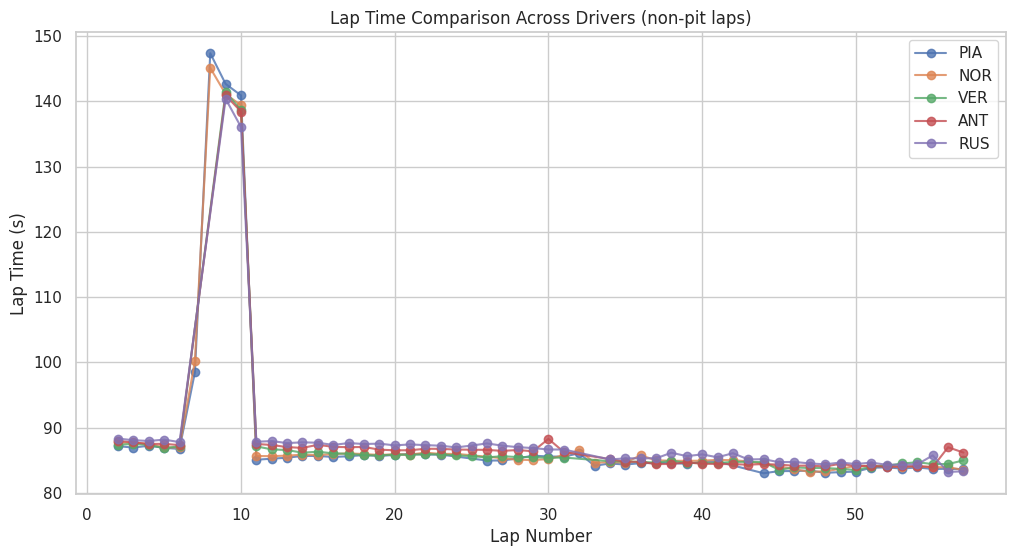

,Driver,FastestLapSec
0,PIA,82.996
1,NOR,83.197
2,RUS,83.198
3,VER,83.498
4,ANT,83.955


,Driver,LapTimeStdSec
0,ANT,12.927783
1,NOR,13.435237
2,PIA,13.878184
3,RUS,12.560619
4,VER,13.258934


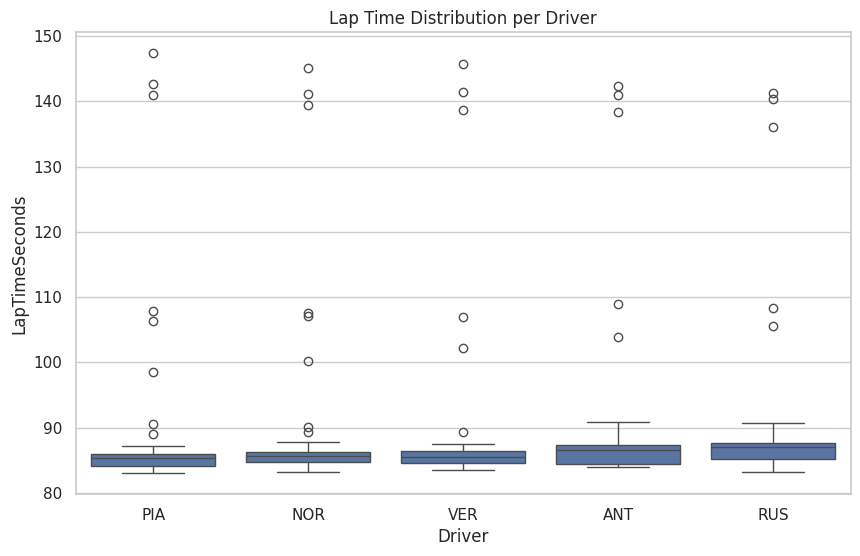

In [ ]:
# -------------------------
# 2. LAP TIME ANALYSIS
# -------------------------
# Plot lap time vs lap number for selected drivers (non-pit laps)
plt.figure(figsize=(12,6))
for d in DRIVERS:
    df = driver_dfs.get(d)
    if df is None: continue
    df_nonpit = df[~df['is_pitlap']].dropna(subset=['LapTimeSeconds'])
    plt.plot(df_nonpit['LapNumber'], df_nonpit['LapTimeSeconds'], marker='o', label=d, alpha=0.8)
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (s)')
plt.title('Lap Time Comparison Across Drivers (non-pit laps)')
plt.legend()
plt.show()

# Fastest lap per driver (table)
fastest = combined.groupby('Driver')['LapTimeSeconds'].min().sort_values().reset_index().rename(columns={'LapTimeSeconds':'FastestLapSec'})
display(fastest)

# Lap time variance (std) per driver
variance = combined.groupby('Driver')['LapTimeSeconds'].std().reset_index().rename(columns={'LapTimeSeconds':'LapTimeStdSec'})
display(variance)

# Boxplot of lap times per driver
plt.figure(figsize=(10,6))
sns.boxplot(data=combined.dropna(subset=['LapTimeSeconds']), x='Driver', y='LapTimeSeconds')
plt.title('Lap Time Distribution per Driver')
plt.show()

,Driver,Compound,LapTimeSeconds
0,ANT,HARD,85.502200
1,ANT,MEDIUM,92.847968
2,NOR,HARD,85.597615
3,NOR,MEDIUM,90.668302
4,PIA,HARD,85.007933
5,PIA,MEDIUM,90.817122
6,RUS,HARD,85.836440
7,RUS,MEDIUM,93.172355
8,VER,HARD,85.275440
9,VER,MEDIUM,92.174677


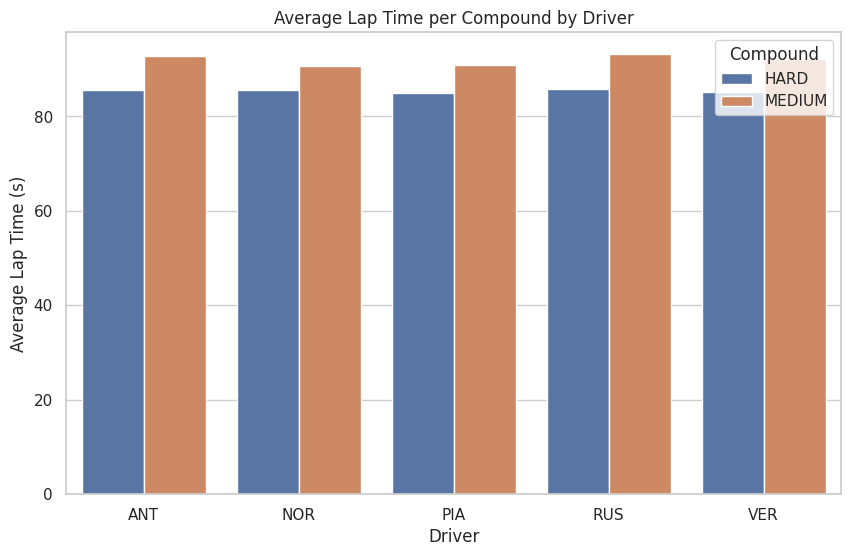

In [ ]:
# -------------------------
# Average Lap Time per Compound
# -------------------------
# Group by driver & compound
df_comp = combined.dropna(subset=['Compound','LapTimeSeconds']).groupby(['Driver','Compound'])['LapTimeSeconds'].mean().reset_index()
display(df_comp)

# Bar chart: average lap time per compound for each driver
plt.figure(figsize=(10,6))
sns.barplot(data=df_comp, x='Driver', y='LapTimeSeconds', hue='Compound')
plt.title('Average Lap Time per Compound by Driver')
plt.ylabel('Average Lap Time (s)')
plt.show()

,Driver,LapNumber,LapTimeSeconds,PitInTime,PitOutTime
177,ANT,7.0,103.942,0 days 01:09:10.654000,NaT
178,ANT,8.0,142.348,NaT,0 days 01:09:42.326000
202,ANT,32.0,90.776,0 days 01:48:06.705000,NaT
203,ANT,33.0,108.921,NaT,0 days 01:48:35.207000
81,NOR,25.0,90.084,0 days 01:37:42.504000,NaT
82,NOR,26.0,107.589,NaT,0 days 01:38:10.457000
100,NOR,44.0,89.254,0 days 02:05:06.462000,NaT
101,NOR,45.0,107.160,NaT,0 days 02:05:34.712000
23,PIA,24.0,90.513,0 days 01:36:13.079000,NaT
24,PIA,25.0,107.924,NaT,0 days 01:36:42.191000


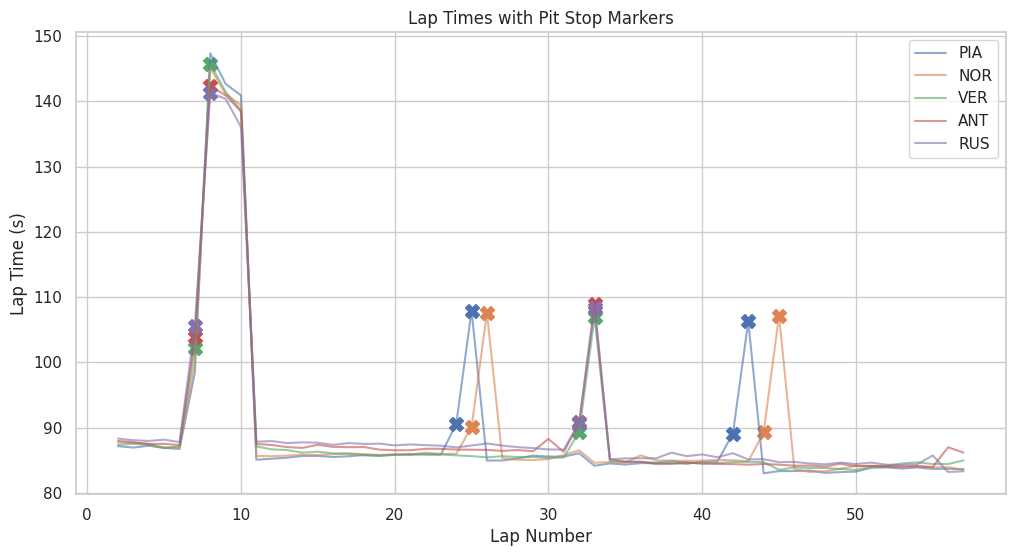

In [ ]:
# -------------------------
# Pit Stop Detection & Visualization
# -------------------------
# Show pit laps table
pitlaps = combined[combined['is_pitlap']==True][['Driver','LapNumber','LapTimeSeconds','PitInTime','PitOutTime']].sort_values(['Driver','LapNumber'])
display(pitlaps.head(20))

# Plot lap times with pit markers
plt.figure(figsize=(12,6))
for d in DRIVERS:
    df = driver_dfs.get(d)
    if df is None: continue
    plt.plot(df['LapNumber'], df['LapTimeSeconds'], label=d, alpha=0.6)
    pits = df[df['is_pitlap']==True]
    plt.scatter(pits['LapNumber'], pits['LapTimeSeconds'], marker='X', s=100)
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (s)')
plt.title('Lap Times with Pit Stop Markers')
plt.legend()
plt.show()

/tmp/ipython-input-3519670533.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  leader_per_lap = combined.dropna(subset=['LapTimeSeconds']).groupby('LapNumber').apply(lambda g: g.loc[g['LapTimeSeconds'].idxmin()]).reset_index(drop=True)


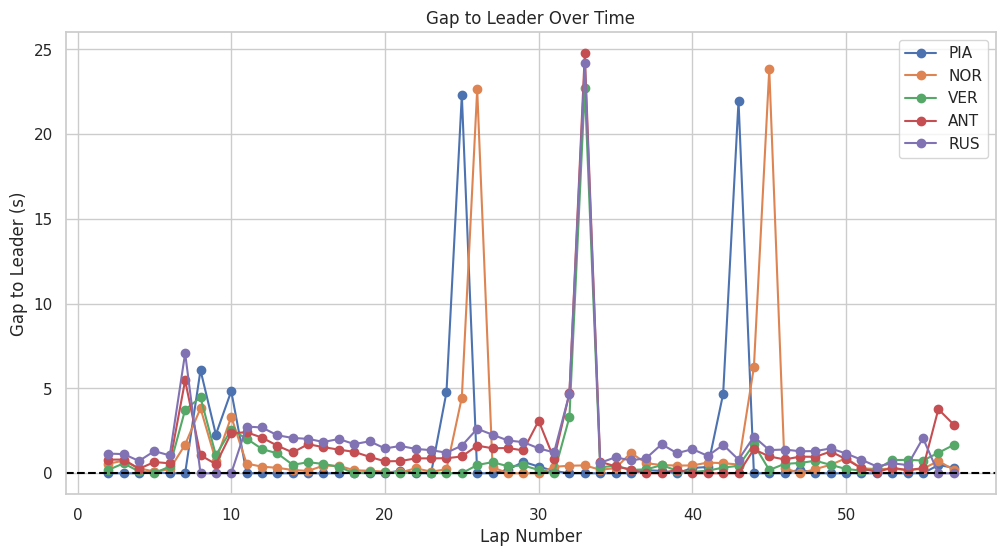

In [ ]:
# -------------------------
# Gap to Leader Over Time
# -------------------------
# Compute leader per lap using combined data: find min lap time per lap number across drivers
leader_per_lap = combined.dropna(subset=['LapTimeSeconds']).groupby('LapNumber').apply(lambda g: g.loc[g['LapTimeSeconds'].idxmin()]).reset_index(drop=True)
leader_per_lap = leader_per_lap[['LapNumber','Driver','LapTimeSeconds']].rename(columns={'Driver':'LeaderDriver','LapTimeSeconds':'LeaderLapTime'})

# Merge leader info into combined
merged_gap = combined.merge(leader_per_lap[['LapNumber','LeaderDriver','LeaderLapTime']], on='LapNumber', how='left')
merged_gap['GapToLeader'] = merged_gap['LapTimeSeconds'] - merged_gap['LeaderLapTime']

# Plot gap to leader for each driver
plt.figure(figsize=(12,6))
for d in DRIVERS:
    df = merged_gap[merged_gap['Driver']==d]
    plt.plot(df['LapNumber'], df['GapToLeader'], marker='o', label=d)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Lap Number')
plt.ylabel('Gap to Leader (s)')
plt.title('Gap to Leader Over Time')
plt.legend()
plt.show()

,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,0 days 00:00:45.438000,29.8,19.0,1016.5,False,35.1,176,1.2
1,0 days 00:01:45.453000,29.7,19.0,1016.5,False,35.0,182,1.2
2,0 days 00:02:45.452000,29.7,19.0,1016.5,False,34.9,156,1.1
3,0 days 00:03:45.466000,29.6,19.0,1016.5,False,34.9,201,0.8
4,0 days 00:04:45.449000,29.6,19.0,1016.5,False,34.8,219,0.8


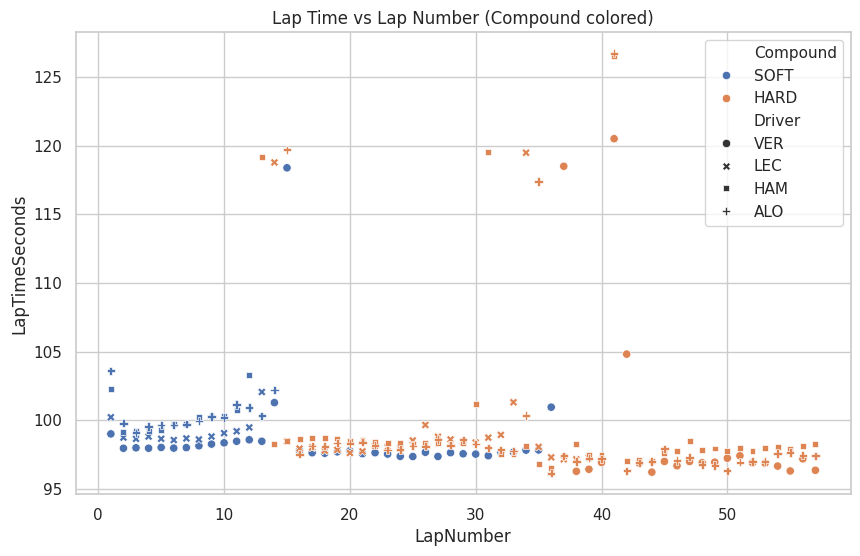

In [ ]:
# -------------------------
# Weather Impact Analysis
# -------------------------
if hasattr(session, 'weather_data') and session.weather_data is not None:
    try:
        w = session.weather_data
        display(w.head())
    except Exception as e:
        print('Weather data not available or not in expected format.', e)
else:
    print('No weather data available for this session.')

# As an approximate proxy, show LapTime vs LapNumber colored by Compound (already done earlier)
plt.figure(figsize=(10,6))
sns.scatterplot(data=combined.dropna(subset=['LapTimeSeconds']), x='LapNumber', y='LapTimeSeconds', hue='Compound', style='Driver')
plt.title('Lap Time vs Lap Number (Compound colored)')
plt.show()

In [ ]:
# -------------------------
# Telemetry Analysis (Speed, Throttle, Brake) - for up to 2 drivers
# -------------------------
for d in TELEMETRY_DRIVERS:
    try:
        driver_lap = session.laps.pick_driver(d).pick_fastest()
        tel = session.laps.pick_driver(d).get_telemetry(driver_lap['LapNumber'])
        # Speed plot over distance
        plt.figure(figsize=(12,4))
        plt.plot(tel['Distance'], tel['Speed'], label=f'{d} Speed')
        plt.xlabel('Distance (m)')
        plt.ylabel('Speed (km/h)')
        plt.title(f'Speed Trace for {d} - Lap {int(driver_lap["LapNumber"])}')
        plt.legend()
        plt.show()
        # Throttle & Brake overlay (if present)
        plt.figure(figsize=(12,4))
        if 'Throttle' in tel.columns and 'Brake' in tel.columns:
            plt.plot(tel['Distance'], tel['Throttle'], label='Throttle')
            plt.plot(tel['Distance'], tel['Brake'], label='Brake')
            plt.xlabel('Distance (m)')
            plt.title(f'Throttle & Brake Trace for {d}')
            plt.legend()
            plt.show()
    except Exception as e:
        print('Telemetry not available for', d, e)

Telemetry not available for VER Laps.get_telemetry() takes 1 positional argument but 2 were given
Telemetry not available for LEC Laps.get_telemetry() takes 1 positional argument but 2 were given


/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/usr/local/lib/python3.12/dist-packages/fastf1/core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


,Driver,Stint,LapsInStint
0,ALO,1.0,14
1,ALO,2.0,20
2,ALO,3.0,23
3,HAM,1.0,12
4,HAM,2.0,18
5,HAM,3.0,27
6,LEC,1.0,13
7,LEC,2.0,20
8,LEC,3.0,7
9,VER,1.0,14


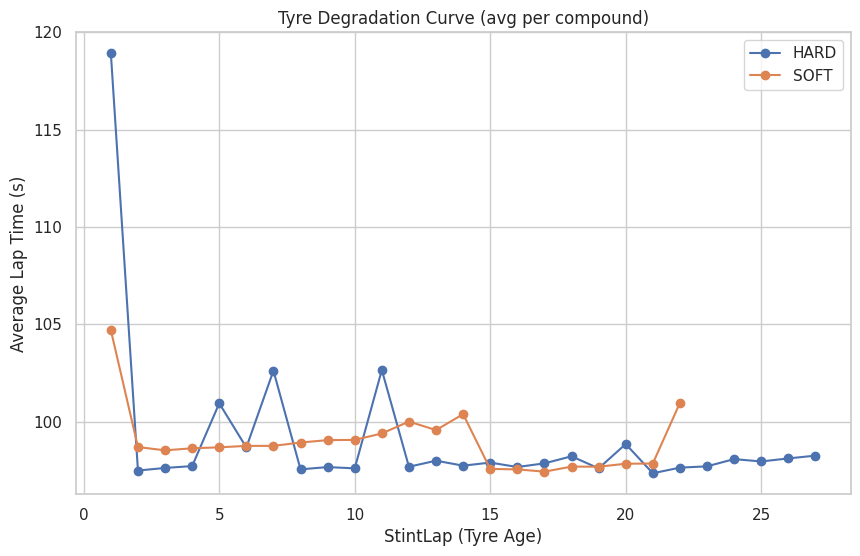

In [ ]:
# -------------------------
# Tyre & Stint Analysis
# -------------------------
# Number of laps per stint distribution
stint_counts = combined.dropna(subset=['Stint']).groupby(['Driver','Stint'])['LapNumber'].count().reset_index(name='LapsInStint')
display(stint_counts.head(20))

# Tyre degradation curves - mean lap time per stint lap for each compound aggregated across drivers
if 'StintLap' in combined.columns:
    deg = combined.dropna(subset=['StintLap','LapTimeSeconds']).groupby(['Compound','StintLap'])['LapTimeSeconds'].mean().reset_index()
    plt.figure(figsize=(10,6))
    for comp in deg['Compound'].unique():
        dfc = deg[deg['Compound']==comp]
        plt.plot(dfc['StintLap'], dfc['LapTimeSeconds'], marker='o', label=comp)
    plt.xlabel('StintLap (Tyre Age)')
    plt.ylabel('Average Lap Time (s)')
    plt.title('Tyre Degradation Curve (avg per compound)')
    plt.legend()
    plt.show()
else:
    print('StintLap not available for this session.')

,Driver,LapNumber,PitDurationSec


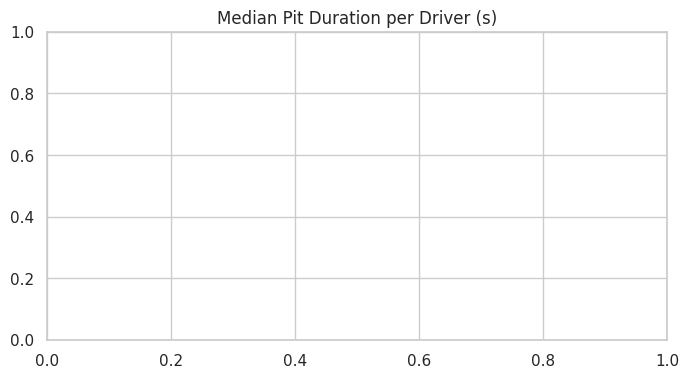

In [ ]:
# -------------------------
# Pit Stop Analysis
# -------------------------
# Estimate pit stop duration where PitInTime and PitOutTime exist
if 'PitInTime' in combined.columns and 'PitOutTime' in combined.columns:
    pit_info = combined.dropna(subset=['PitInTime','PitOutTime']).copy()
    try:
        pit_info['PitDurationSec'] = (pd.to_timedelta(pit_info['PitOutTime']) - pd.to_timedelta(pit_info['PitInTime'])).dt.total_seconds()
    except Exception:
        pit_info['PitDurationSec'] = pit_info['LapTimeSeconds'] - pit_info.groupby(['Driver'])['LapTimeSeconds'].transform(lambda x: x.median())
    display(pit_info[['Driver','LapNumber','PitDurationSec']].head(20))
    medpit = pit_info.groupby('Driver')['PitDurationSec'].median().reset_index()
    plt.figure(figsize=(8,4))
    sns.barplot(data=medpit, x='Driver', y='PitDurationSec')
    plt.title('Median Pit Duration per Driver (s)')
    plt.show()
else:
    print('PitInTime/PitOutTime not fully available; using pit lap markers for analysis.')
    num_pits = combined.groupby('Driver')['is_pitlap'].sum().reset_index().rename(columns={'is_pitlap':'NumPitLaps'})
    display(num_pits)

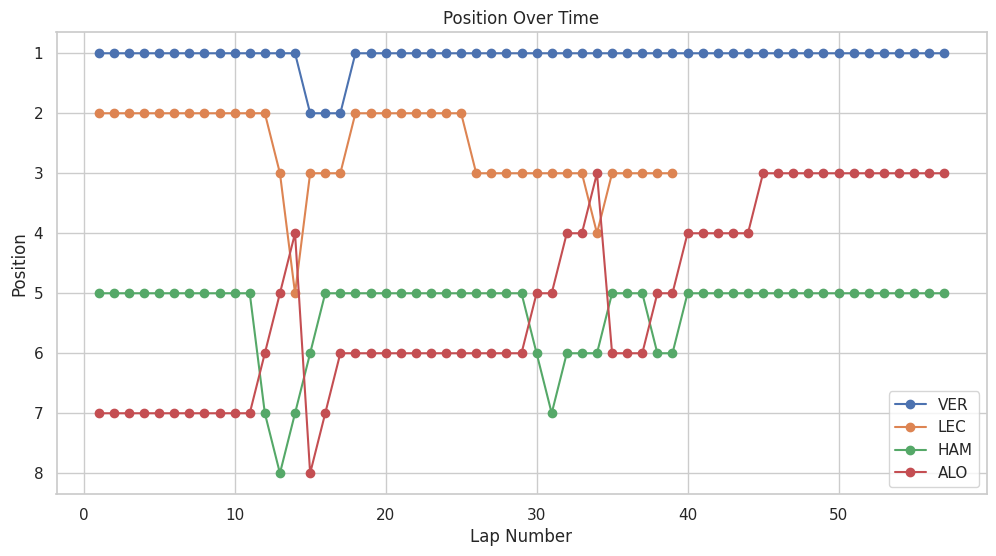

,Driver,Sector1Time,Sector2Time,Sector3Time
0,ALO,0 days 00:00:32.239410714,0 days 00:00:43.033789473,0 days 00:00:24.243456140
1,HAM,0 days 00:00:32.114089285,0 days 00:00:43.338368421,0 days 00:00:24.290894736
2,LEC,0 days 00:00:32.461578947,0 days 00:00:42.947512820,0 days 00:00:24.206820512
3,VER,0 days 00:00:32.058535714,0 days 00:00:42.663228070,0 days 00:00:24.155982456


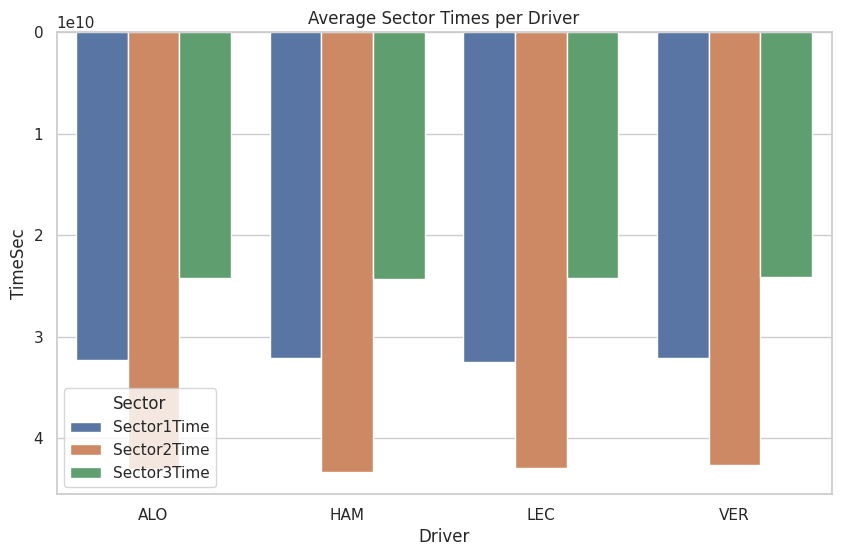

In [ ]:
# -------------------------
# Position Over Time & Sector Breakdown
# -------------------------
if 'Position' in combined.columns:
    plt.figure(figsize=(12,6))
    for d in DRIVERS:
        df = combined[combined['Driver']==d]
        plt.plot(df['LapNumber'], df['Position'], marker='o', label=d)
    plt.gca().invert_yaxis()
    plt.xlabel('Lap Number')
    plt.ylabel('Position')
    plt.title('Position Over Time')
    plt.legend()
    plt.show()
else:
    if results is not None:
        display(results[['Abbreviation','Position','Grid','Time']].head(20))
    else:
        print('Position info not available in combined dataset or results.')

if all(col in combined.columns for col in ['Sector1Time','Sector2Time','Sector3Time']):
    sector_avg = combined.groupby('Driver')[['Sector1Time','Sector2Time','Sector3Time']].mean().reset_index()
    display(sector_avg)
    sector_avg_melt = sector_avg.melt(id_vars='Driver', value_vars=['Sector1Time','Sector2Time','Sector3Time'], var_name='Sector', value_name='TimeSec')
    plt.figure(figsize=(10,6))
    sns.barplot(data=sector_avg_melt, x='Driver', y='TimeSec', hue='Sector')
    plt.title('Average Sector Times per Driver')
    plt.show()
else:
    print('Sector times not available in this session for all laps.')

In [ ]:
# -------------------------
# Dataset Operations Showcase
# -------------------------
d1, d2 = DRIVERS[0], DRIVERS[1] if len(DRIVERS)>1 else DRIVERS[0]
concat_example = pd.concat([driver_dfs[d1].assign(Driver=d1), driver_dfs[d2].assign(Driver=d2)], ignore_index=True)
print('Concat example shape:', concat_example.shape)
display(concat_example.head())

if 'leader_per_lap' in globals():
    merged_example = combined.merge(leader_per_lap[['LapNumber','LeaderLapTime']], on='LapNumber', how='left')
    display(merged_example[['Driver','LapNumber','LapTimeSeconds','LeaderLapTime']].head())
else:
    print('leader_per_lap not in globals. Run Gap to Leader section first.')

team_info = combined[['Driver','Team']].drop_duplicates().set_index('Driver')
sample = concat_example.set_index('Driver').join(team_info, how='left', rsuffix='_team')
display(sample.reset_index().head())

Concat example shape: (97, 34)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds,is_pitlap,StintLap
0,0 days 01:04:15.902000,VER,1,0 days 00:01:39.019000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.414000,...,NaT,12,1.0,None,,False,False,99.019,False,1
1,0 days 01:05:53.876000,VER,1,0 days 00:01:37.974000,2.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.504000,...,NaT,12,1.0,None,,False,True,97.974,False,2
2,0 days 01:07:31.882000,VER,1,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,...,NaT,1,1.0,None,,False,True,98.006,False,3
3,0 days 01:09:09.858000,VER,1,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,...,NaT,1,1.0,None,,False,True,97.976,False,4
4,0 days 01:10:47.893000,VER,1,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,...,NaT,1,1.0,None,,False,True,98.035,False,5


,Driver,LapNumber,LapTimeSeconds,LeaderLapTime
0,VER,1.0,99.019,99.019
1,VER,2.0,97.974,97.974
2,VER,3.0,98.006,98.006
3,VER,4.0,97.976,97.976
4,VER,5.0,98.035,98.035


,Driver,Time,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds,is_pitlap,StintLap,Team_team
0,VER,0 days 01:04:15.902000,1,0 days 00:01:39.019000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:42.414000,...,12,1.0,None,,False,False,99.019,False,1,Red Bull Racing
1,VER,0 days 01:05:53.876000,1,0 days 00:01:37.974000,2.0,1.0,NaT,NaT,0 days 00:00:31.342000,0 days 00:00:42.504000,...,12,1.0,None,,False,True,97.974,False,2,Red Bull Racing
2,VER,0 days 01:07:31.882000,1,0 days 00:01:38.006000,3.0,1.0,NaT,NaT,0 days 00:00:31.388000,0 days 00:00:42.469000,...,1,1.0,None,,False,True,98.006,False,3,Red Bull Racing
3,VER,0 days 01:09:09.858000,1,0 days 00:01:37.976000,4.0,1.0,NaT,NaT,0 days 00:00:31.271000,0 days 00:00:42.642000,...,1,1.0,None,,False,True,97.976,False,4,Red Bull Racing
4,VER,0 days 01:10:47.893000,1,0 days 00:01:38.035000,5.0,1.0,NaT,NaT,0 days 00:00:31.244000,0 days 00:00:42.724000,...,1,1.0,None,,False,True,98.035,False,5,Red Bull Racing


In [ ]:
# -------------------------
# Save cleaned combined dataset
# -------------------------
out_path = 'bahrain23_combined_cleaned.csv'
combined.to_csv(out_path, index=False)
print('Saved combined cleaned dataset to', out_path)

Saved combined cleaned dataset to bahrain23_combined_cleaned.csv
